In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Regression modeling and diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

# Regularization techniques
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Normality test
from scipy.stats import shapiro

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style
sns.set(style="whitegrid")

# 1. Load Data
df = pd.read_csv("product_monthly_panel.csv")

# 2. Data Preprocessing
# Convert submission_time to datetime
df['submission_time'] = pd.to_datetime(df['submission_time'])

# Handle missing values
df['is_recommended'].fillna(df['is_recommended'].mean(), inplace=True)
df['helpfulness'].fillna(df['helpfulness'].mean(), inplace=True)
df.dropna(subset=['rating'], inplace=True)

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['brand_name', 'skin_tone', 'eye_color', 'skin_type', 'hair_color'], drop_first=True)

# Define features and target
X = df_encoded.drop(['product_id', 'submission_time', 'rating'], axis=1)
y = df_encoded['rating']


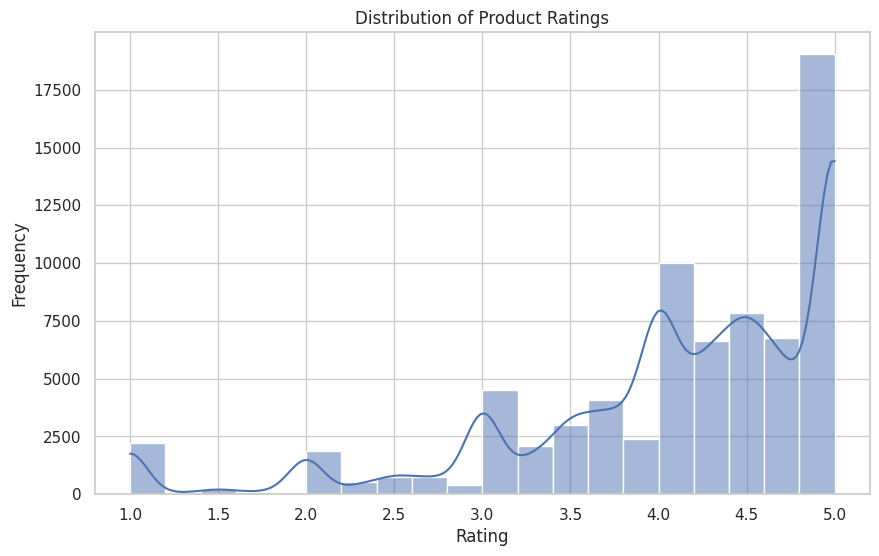

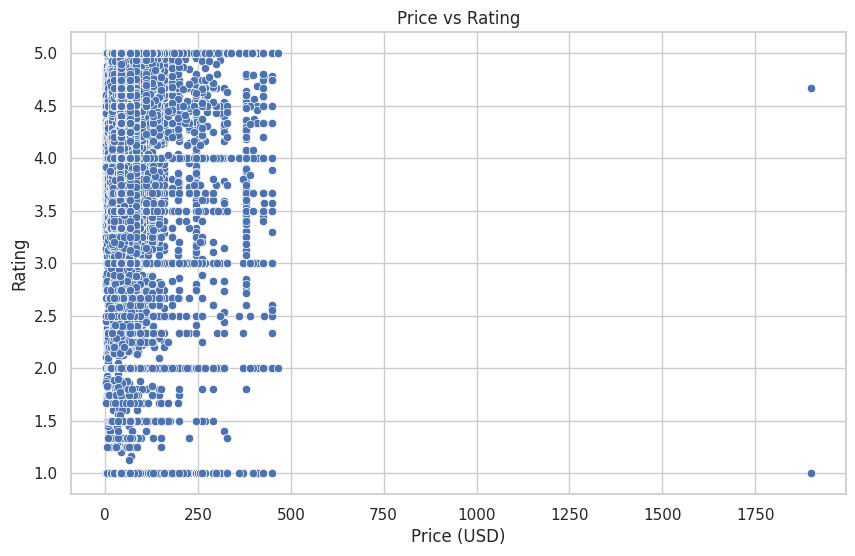

In [7]:
# 3. Exploratory Data Analysis
plt.figure(figsize=(10,6))
sns.histplot(df['rating'], bins=20, kde=True)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='price_usd', y='rating', data=df)
plt.title('Price vs Rating')
plt.xlabel('Price (USD)')
plt.ylabel('Rating')
plt.show()

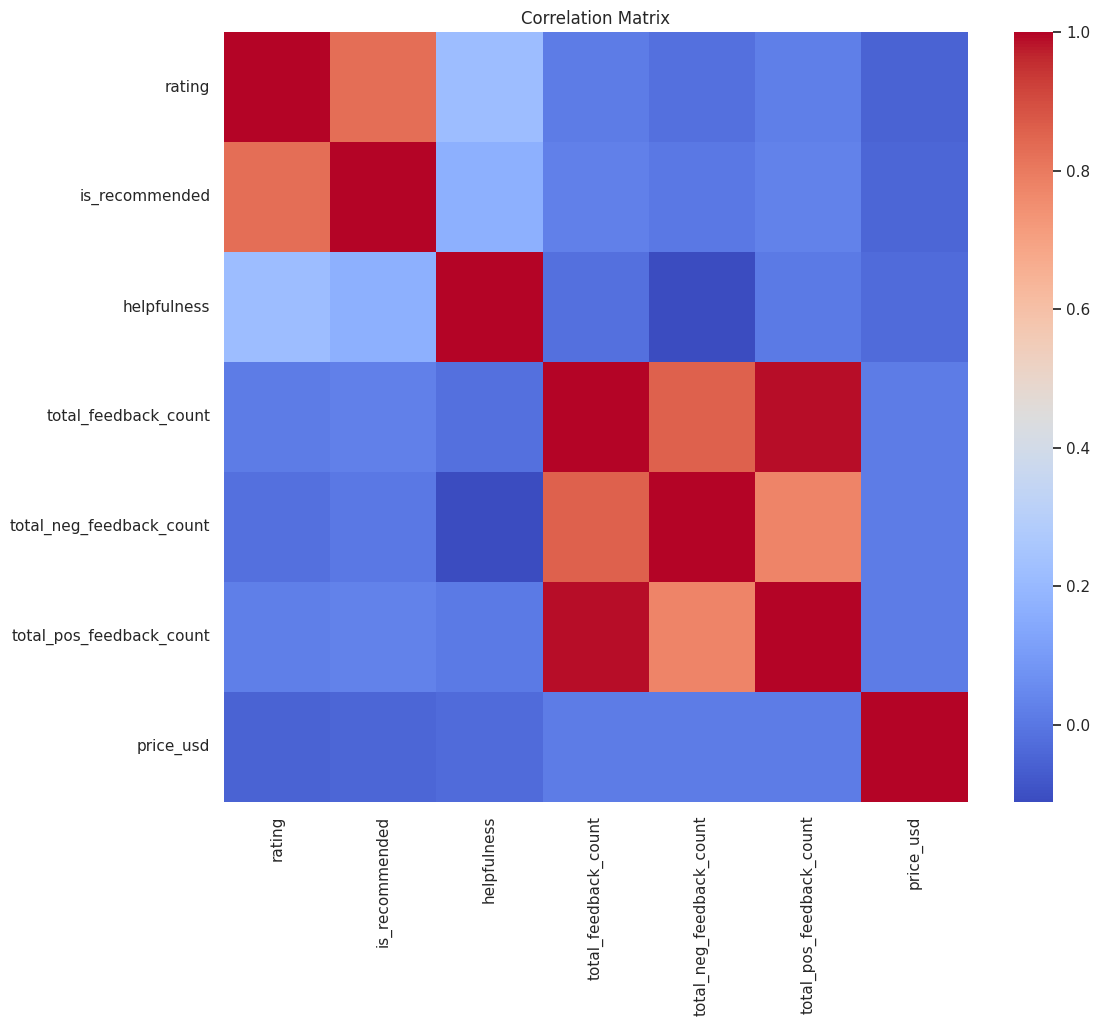

In [9]:
# Correlation matrix (only numeric columns)
numeric_df = df_encoded.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [11]:
#4 Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Select only numeric columns for VIF calculation
numeric_X = df_encoded.select_dtypes(include=[np.number])

# Sample data to reduce memory usage if needed
if len(numeric_X) > 5000:
    numeric_X_sampled = numeric_X.sample(n=5000, random_state=42)
else:
    numeric_X_sampled = numeric_X.copy()

# Add constant term
X_with_const = sm.add_constant(numeric_X_sampled)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                    for i in range(X_with_const.shape[1])]

# Display VIF results
print("\nVariance Inflation Factor (VIF):")
print(vif_data.sort_values(by="VIF", ascending=False))



Variance Inflation Factor (VIF):
                    Feature        VIF
4      total_feedback_count        inf
5  total_neg_feedback_count        inf
6  total_pos_feedback_count        inf
0                     const  34.761542
1                    rating   3.359973
2            is_recommended   3.314741
3               helpfulness   1.079008
7                 price_usd   1.003420


In [12]:
# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 7. Modeling

# 7.1 OLS Regression
X_train_ols = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_ols).fit()
print("\nOLS Regression Model Summary:")
print(ols_model.summary())


OLS Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     831.2
Date:                Sun, 23 Feb 2025   Prob (F-statistic):               0.00
Time:                        02:58:12   Log-Likelihood:                -43683.
No. Observations:               58617   AIC:                         8.771e+04
Df Residuals:                   58444   BIC:                         8.926e+04
Df Model:                         172                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [13]:
# 7.2 Ridge Regression
ridge = Ridge()
ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_cv = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
print("\nBest Ridge Parameters:", ridge_cv.best_params_)



Best Ridge Parameters: {'alpha': 10.0}


In [14]:
# 7.3 Lasso Regression
lasso = Lasso(max_iter=10000)
lasso_params = {'alpha': [0.01, 0.1, 1.0, 10.0]}
lasso_cv = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train, y_train)
print("\nBest Lasso Parameters:", lasso_cv.best_params_)



Best Lasso Parameters: {'alpha': 0.01}


In [15]:
# 7.4 Elastic Net Regression
elastic = ElasticNet(max_iter=10000)
elastic_params = {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.1, 0.5, 0.9]}
elastic_cv = GridSearchCV(elastic, elastic_params, cv=5, scoring='neg_mean_squared_error')
elastic_cv.fit(X_train, y_train)
print("\nBest Elastic Net Parameters:", elastic_cv.best_params_)



Best Elastic Net Parameters: {'alpha': 0.1, 'l1_ratio': 0.1}


In [20]:
from sklearn.metrics import mean_squared_error, r2_score

# 8. Model Evaluation
models = {
    'OLS': ols_model,
    'Ridge': ridge_cv.best_estimator_,
    'Lasso': lasso_cv.best_estimator_,
    'Elastic Net': elastic_cv.best_estimator_
}

results = []

for name, model in models.items():
    if name == 'OLS':
        # Ensure the same columns used during training
        X_train_ols = sm.add_constant(X_train, has_constant='add')
        X_test_ols = sm.add_constant(X_test, has_constant='add')

        # Align columns between train and test
        X_test_ols = X_test_ols[X_train_ols.columns]

        y_pred = model.predict(X_test_ols)
    else:
        y_pred = model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Append results
    results.append({
        'Model': name,
        'MSE': mse,
        'R2': r2
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display the comparison
print("\nModel Comparison:")
print(results_df)



Model Comparison:
         Model       MSE        R2
0          OLS  0.255871  0.714511
1        Ridge  0.255869  0.714512
2        Lasso  0.259585  0.710366
3  Elastic Net  0.265555  0.703706


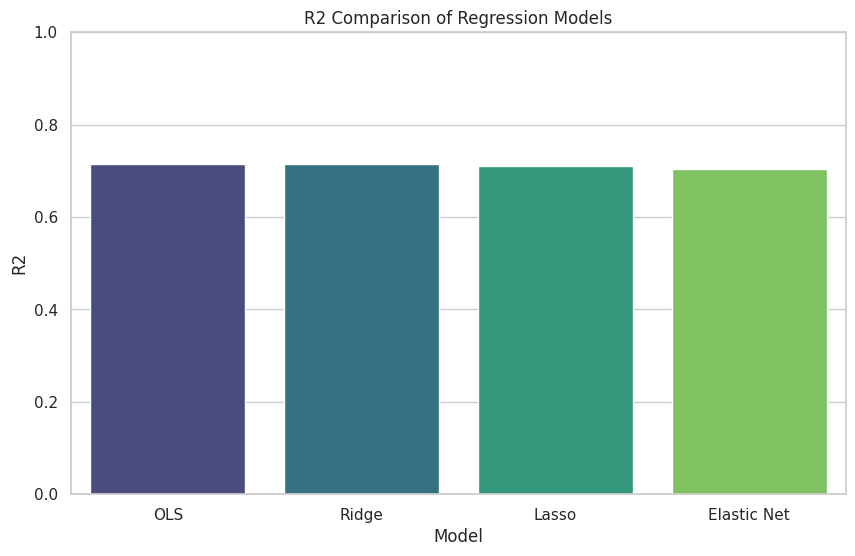

In [21]:
# Plot R2 comparison
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='R2', data=results_df, palette='viridis')
plt.title('R2 Comparison of Regression Models')
plt.ylim(0,1)
plt.show()

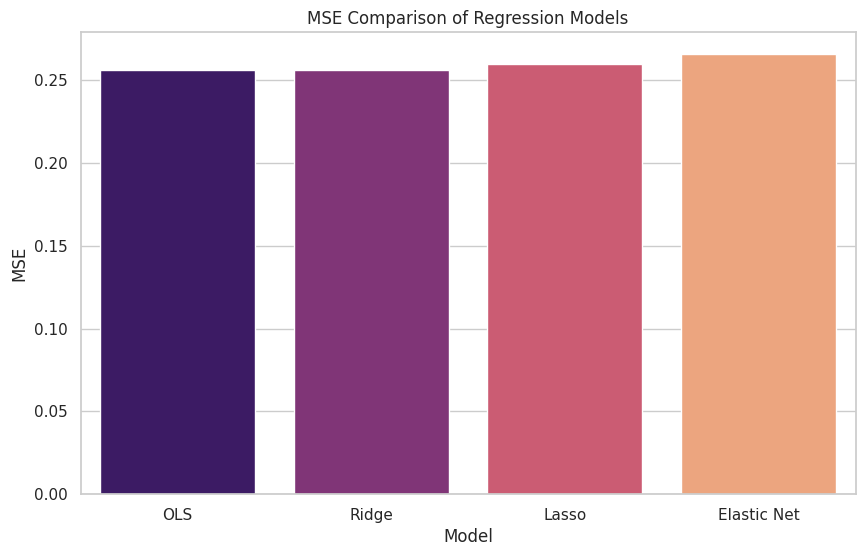

In [22]:
# Plot MSE comparison
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='MSE', data=results_df, palette='magma')
plt.title('MSE Comparison of Regression Models')
plt.show()

In [23]:
# 9. Regression Diagnostics for Best Model
best_model_name = results_df.sort_values('R2', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

if best_model_name == 'OLS':
    y_pred_best = best_model.predict(sm.add_constant(X_test))
else:
    y_pred_best = best_model.predict(X_test)

residuals_best = y_test - y_pred_best


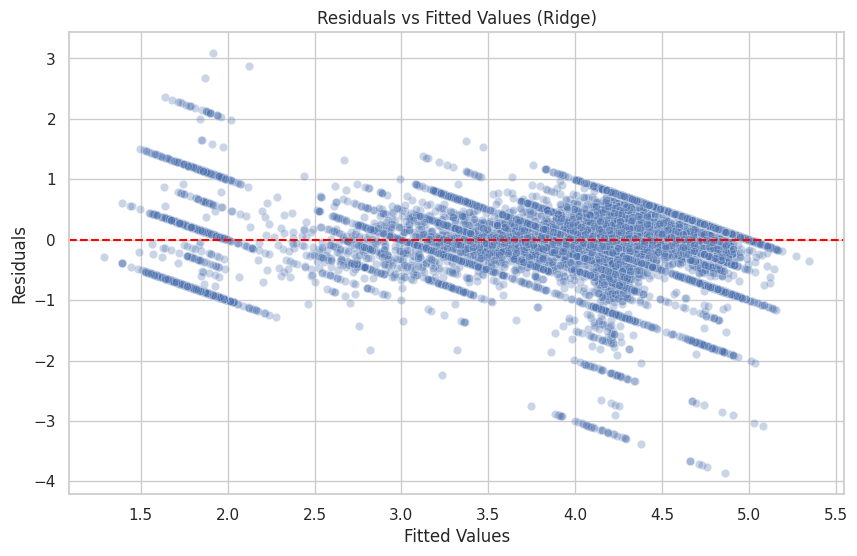

In [24]:
# Residuals vs Fitted
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred_best, y=residuals_best, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title(f'Residuals vs Fitted Values ({best_model_name})')
plt.show()

In [25]:
# Durbin-Watson Test
dw_stat = durbin_watson(residuals_best)
print(f'\nDurbin-Watson statistic for {best_model_name}: {dw_stat:.4f}')



Durbin-Watson statistic for Ridge: 2.0113


In [26]:
# Breusch-Pagan Test
bp_test = het_breuschpagan(residuals_best, sm.add_constant(X_test))
print(f'\nBreusch-Pagan Test for {best_model_name}:')
print(f'Lagrange multiplier statistic: {bp_test[0]:.4f}')
print(f'p-value: {bp_test[1]:.4f}')



Breusch-Pagan Test for Ridge:
Lagrange multiplier statistic: 1234.6505
p-value: 0.0000


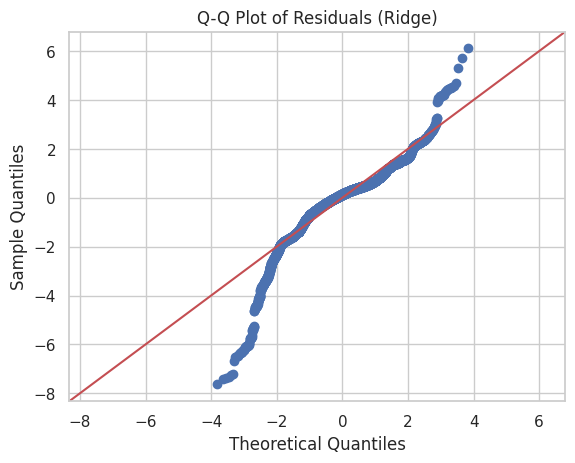

In [27]:
# Q-Q Plot
sm.qqplot(residuals_best, line='45', fit=True)
plt.title(f'Q-Q Plot of Residuals ({best_model_name})')
plt.show()


In [28]:
# Shapiro-Wilk Test
shapiro_test = shapiro(residuals_best.sample(min(5000, len(residuals_best)), random_state=42))
print(f'Shapiro-Wilk Test Statistic: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}')


Shapiro-Wilk Test Statistic: 0.9047, p-value: 0.0000
